<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Feed-Forward Networks</h1>
<p>This section is basically a continuation of the ANN section.</p>
<h2>MNIST dataset</h2>
<p>The MNSIT dataset is a lot of hard-written digits, one of the most famous ML datasets.</p>
</div>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as khg

c:\Users\szala\Documents\onkepzes\ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
path = khg.dataset_download("oddrationale/mnist-in-csv")
path

'C:\\Users\\szala\\.cache\\kagglehub\\datasets\\oddrationale\\mnist-in-csv\\versions\\2'

In [38]:
testData = np.loadtxt('../../assets/mnist/mnist_test.csv', delimiter=',', dtype=str)
trainData = np.loadtxt('../../assets/mnist/mnist_train.csv', delimiter=',', dtype=str)

print(trainData.shape)
print(testData.shape)

trainData

(60001, 785)
(10001, 785)


array([['label', '1x1', '1x2', ..., '28x26', '28x27', '28x28'],
       ['5', '0', '0', ..., '0', '0', '0'],
       ['0', '0', '0', ..., '0', '0', '0'],
       ...,
       ['5', '0', '0', ..., '0', '0', '0'],
       ['6', '0', '0', ..., '0', '0', '0'],
       ['8', '0', '0', ..., '0', '0', '0']],
      shape=(60001, 785), dtype='<U5')

In [39]:
trainLabels = np.array(trainData[1:,0], dtype=float)
trainData = np.array(trainData[1:,1:], dtype=float)

print(trainData.shape)
print(trainLabels.shape)
trainLabels

(60000, 784)
(60000,)


array([5., 0., 4., ..., 5., 6., 8.], shape=(60000,))

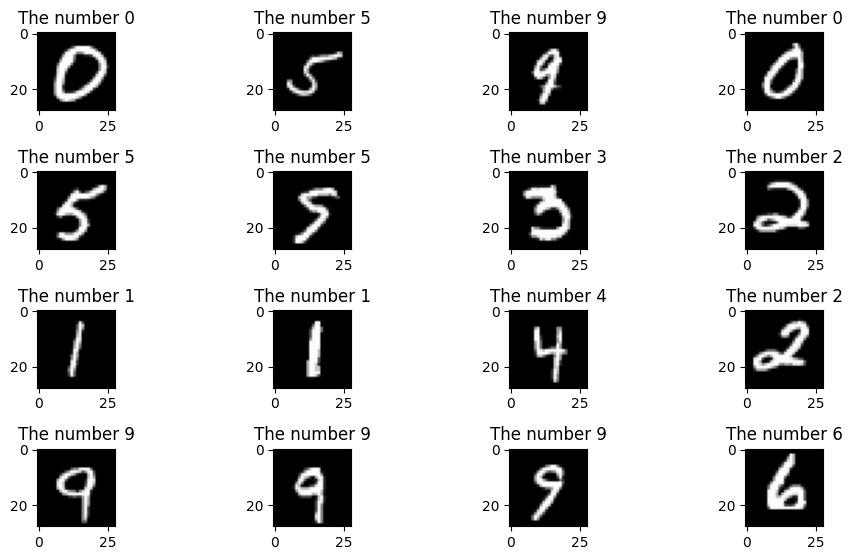

In [49]:
def plotSample(digit: int = None):
    fig, axs = plt.subplots(4, 4, figsize=(10, 6))

    if digit != None:
        data = trainData[np.where(trainLabels == digit)]
        label = trainLabels[np.where(trainLabels == digit)]
    else:
        data = trainData
        label = trainLabels

    for ax in axs.flatten():
        randimImageToShow = np.random.randint(0, data.shape[0])
        img = np.reshape(data[randimImageToShow], (28, 28))
        ax.imshow(img, cmap='gray')

        ax.set_title('The number %i'%label[randimImageToShow])

    plt.tight_layout(rect=[0,0,1,.95])
    plt.show()

plotSample()

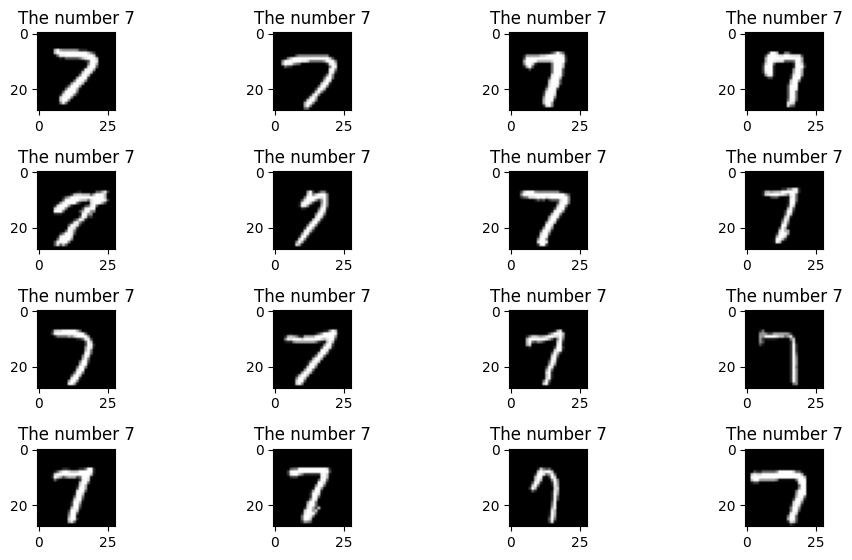

In [50]:
plotSample(7)

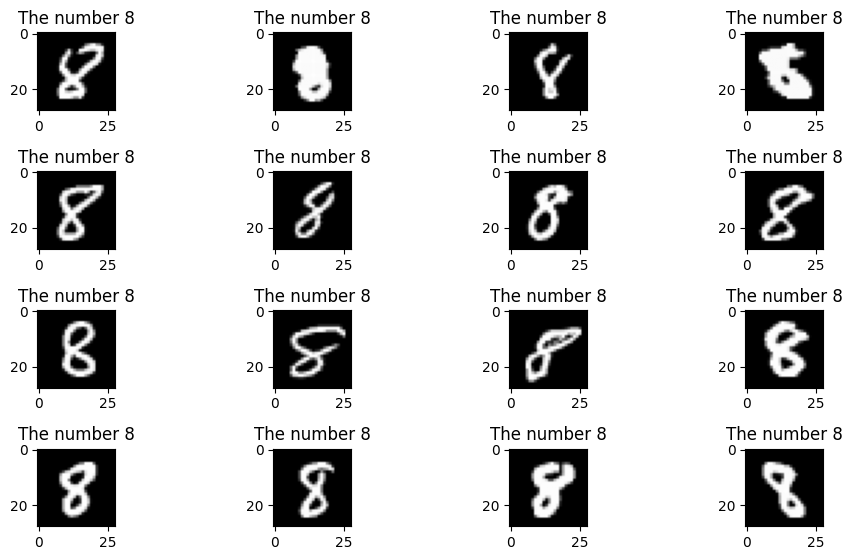

In [51]:
plotSample(8)

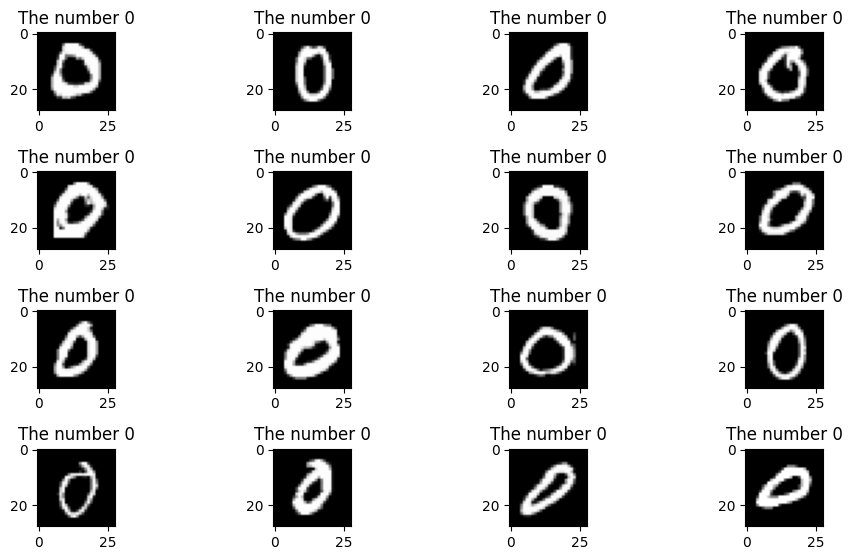

In [52]:
plotSample(0)

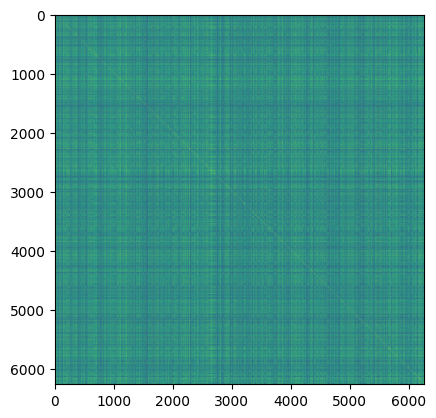

In [61]:
# Find out how similar the images are
digit = 7

data = trainData[np.where(trainLabels == digit)]
label = trainLabels[np.where(trainLabels == digit)]
C = np.corrcoef(data[:,:])
plt.imshow(C)
plt.show()

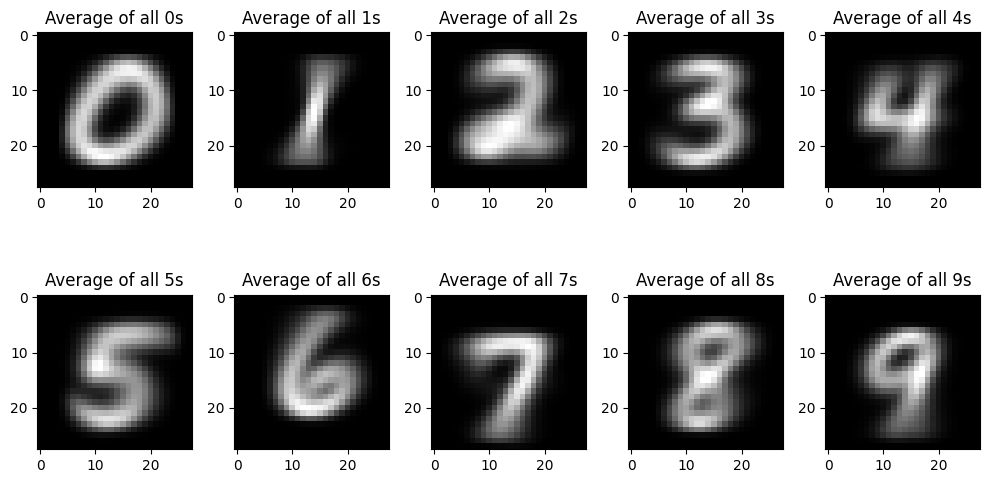

In [80]:
fig, axs = plt.subplots(2, 5, figsize=(10, 6))
for i,ax in enumerate(axs.flatten()):
    data = trainData[np.where(trainLabels == i)]
    label = trainLabels[np.where(trainLabels == i)]
    
    ax.imshow(np.reshape(np.mean(data, axis=0), (28, 28)), cmap='gray')
    ax.set_title(f'Average of all {i}s')

plt.tight_layout(rect=[0,0,1,.95])
plt.show()